In [6]:
import polars as pl
import os
import json
from pathlib import Path

NOTEBOOK_DIR = Path(os.path.abspath('')).resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]  # Fast_Data_Discovery
PAPER_ROOT = PROJECT_ROOT.parent / 'Matryoshka'

exp_path = NOTEBOOK_DIR / 'logs'
exp_dir = os.listdir(exp_path)
runtime_res = {}
for exp in exp_dir:
    if not os.path.isdir(exp_path / exp):
        continue
    comb_log = exp_path / exp / f'{exp}.log'
    with open(comb_log) as f:
        lines = f.readlines()
    for i in range(len(lines)):
        lines[i] = json.loads(lines[i])
    df = pl.from_records(lines, orient='col')
    runtime = df.select(pl.col('runtime').sum()).to_series()[0]
    runtime_res[exp] = runtime
runtime_df = pl.from_dicts([{'experiment': k, 'runtime': v} for k, v in runtime_res.items()])
runtime_df = runtime_df.with_columns(
    pl.col('experiment').str.split('_').list.to_struct(upper_bound=3, fields=['lake', 'table', 'n_cores']).struct.unnest()
)

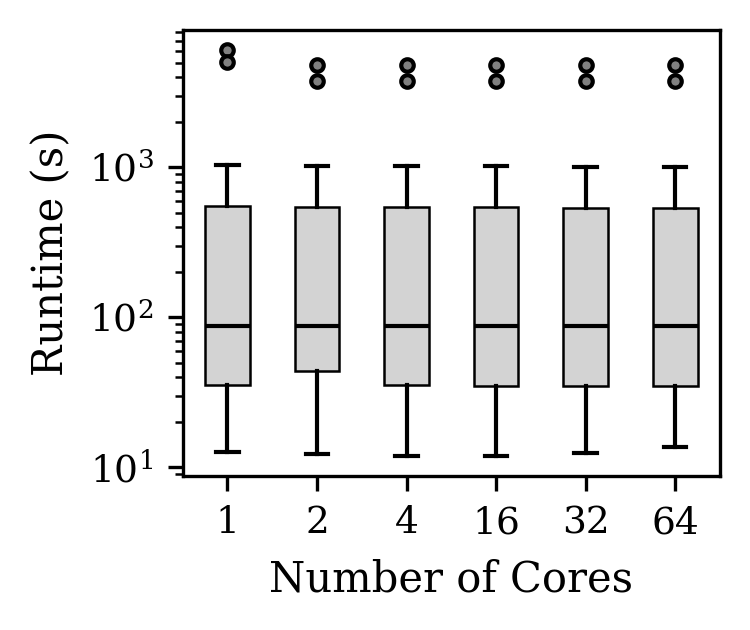

In [11]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'experiments'))
import plots_style
plots_style.apply_style()

plot_df = runtime_df.with_columns(pl.col('n_cores').cast(pl.Int32)).sort('n_cores')
core_values = sorted(plot_df['n_cores'].unique().to_list())

# Prepare data for boxplot: list of runtime arrays, one per n_cores
box_data = [plot_df.filter(pl.col('n_cores') == c)['runtime'].to_list() for c in core_values]

fig, ax = plt.subplots(figsize=(2.4, 2.0))
bp = ax.boxplot(box_data, positions=range(len(core_values)), widths=0.5,
                patch_artist=True, showfliers=True,
                medianprops=dict(color='black', linewidth=1),
                flierprops=dict(marker='o', markersize=3, markerfacecolor='gray'))
for patch in bp['boxes']:
    patch.set_facecolor('lightgray')
    patch.set_edgecolor('black')
    patch.set_linewidth(0.6)

ax.set_yscale('log')
ax.set_xticks(range(len(core_values)))
ax.set_xticklabels([str(c) for c in core_values])
ax.set_xlabel('Number of Cores')
ax.set_ylabel('Runtime (s)')
plt.tight_layout(pad=0.3)
plt.savefig(PAPER_ROOT / 'figures' / 'n_jobs_ablation.pdf')
plt.show()